# Plant Disease Detection — Mauritius Crops
**Crops:** Corn, Potato, Pepper, Tomato
**Models:** Baseline CNN → VGG16 → VGG19 → EfficientNetB0 → EfficientNetB3

## 1. Import Libraries

In [1]:
import os
import shutil
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16, VGG19, EfficientNetB0, EfficientNetB3

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Create Test set from Val
We move 50%  of val images into new test/ folder -one class at a time

In [2]:
BASE_DIR = "../PlantVillage"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

random.seed(42)

if os.path.exists(TEST_DIR):
    print("test/ already exists - Skipping split.")
else:
    os.makedirs(TEST_DIR)
    for cls in os.listdir(VAL_DIR):
        cls_val = os.path.join(VAL_DIR, cls)
        cls_test = os.path.join(TEST_DIR, cls)
        os.makedirs(cls_test)

        images = os.listdir(cls_val)
        random.shuffle(images)
        to_move = images[:len(images) // 2] # 50%

        for img in to_move:
            shutil.move(os.path.join(cls_val, img), os.path.join(cls_test, img))

        print(f"{cls}: {len(images)} total -> {len(images)-len(to_move)} val, {len(to_move)} test")
    

test/ already exists - Skipping split.


In [8]:
# Verify counts
for split in ['train', 'val', 'test']:
    path = os.path.join(BASE_DIR, split)
    total = sum(len(os.listdir(os.path.join(path, c))) for c in os.listdir(path))
    print(f"{split:6s} → {len(os.listdir(path))} classes, {total} images")

train  → 19 classes, 21310 images
val    → 19 classes, 2670 images
test   → 19 classes, 2659 images


## 3. Data Generators (ImageDataGenerator)

### Data Generator FOR CNN

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training : rescale + augmentation
train_datagen =  ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

# Val & Test: only rescale (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

NUM_CLASSES = train_generator.num_classes
CLASS_NAMES = list(train_generator.class_indices.keys())

print("Classes:", CLASS_NAMES)

Found 21310 images belonging to 19 classes.
Found 2670 images belonging to 19 classes.
Found 2659 images belonging to 19 classes.
Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


### Data Generator for VGG16

In [35]:
from tensorflow.keras.applications.vgg16 import preprocess_input

vgg_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

vgg_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

vgg_train_generator = vgg_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

vgg_val_generator = vgg_val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

vgg_test_generator = vgg_val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 21310 images belonging to 19 classes.
Found 2670 images belonging to 19 classes.
Found 2659 images belonging to 19 classes.


### Data Generator for VGG19

In [38]:
from tensorflow.keras.applications.vgg19 import preprocess_input


vgg19_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

vgg19_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

vgg19_train_generator = vgg19_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

vgg19_val_generator = vgg19_val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

vgg19_test_generator = vgg19_val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 21310 images belonging to 19 classes.
Found 2670 images belonging to 19 classes.
Found 2659 images belonging to 19 classes.


### Data Generator for EfficientNet

In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input


efficientNet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

efficientNet_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

efficientNet_train_generator = efficientNet_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

efficientNet_val_generator = efficientNet_val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

efficientNet_test_generator = efficientNet_val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 21310 images belonging to 19 classes.
Found 2670 images belonging to 19 classes.
Found 2659 images belonging to 19 classes.


## 4. Preview Some Training Images

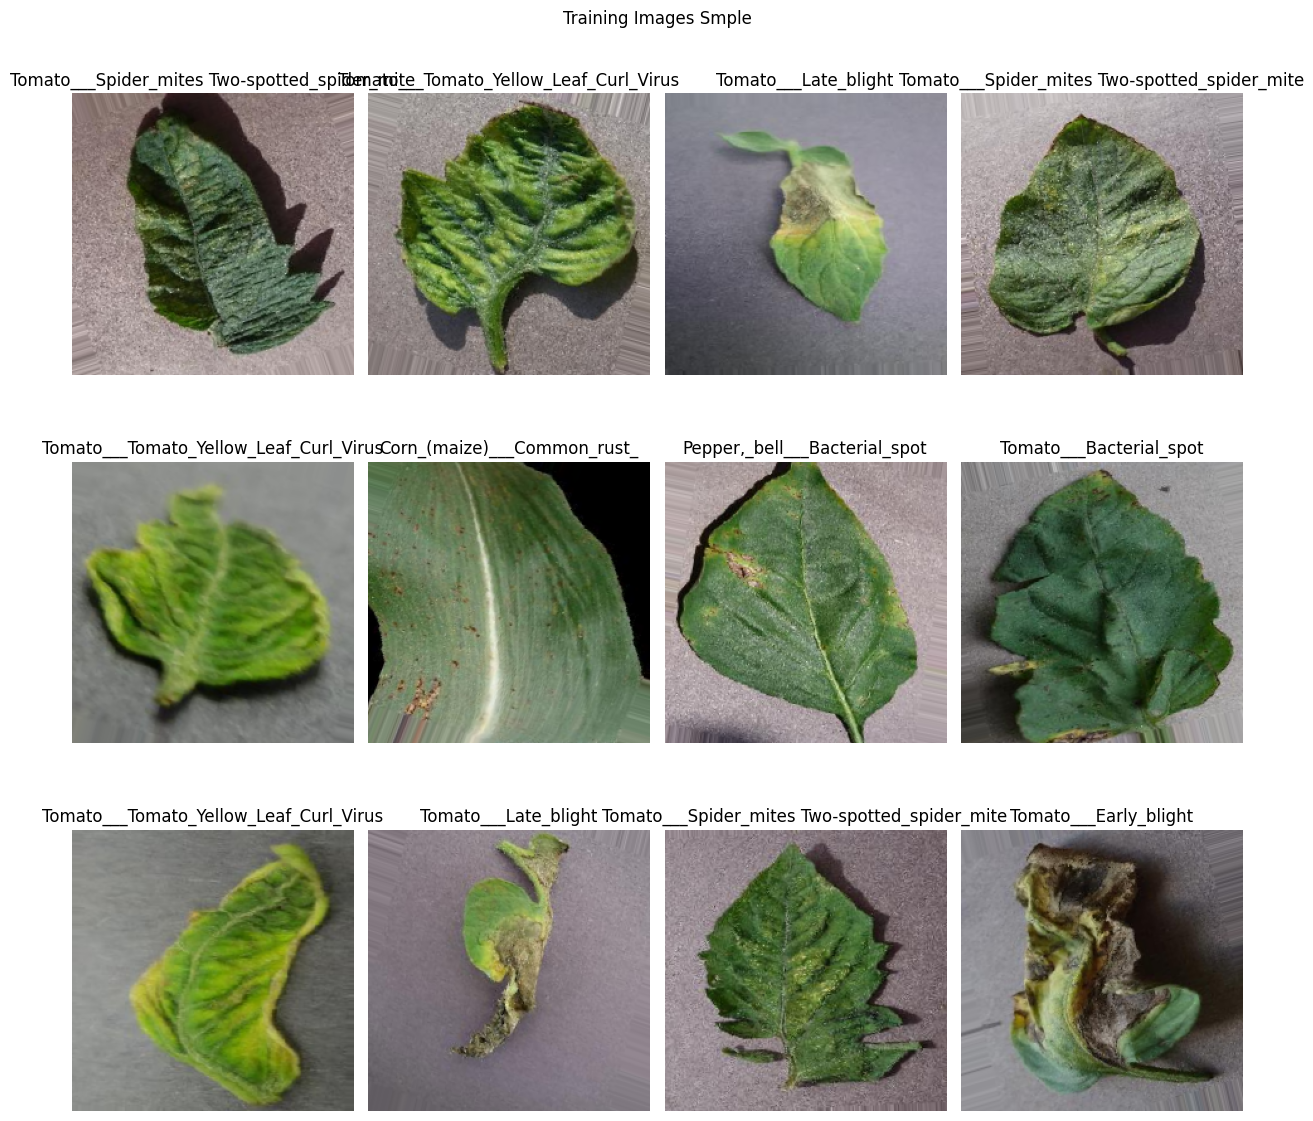

In [10]:
images, labels = next(train_generator) # Get one batch with labels

plt.figure(figsize=(12, 12))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle("Training Images Smple")
plt.tight_layout()
plt.show()

## 5. Helper: Plot Training Curves

In [6]:
def plot_history(history, title):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(acc))

    plt.figure(figsize=(12,5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Loss')

    plt.tight_layout()
    plt.show()
  

## 6. Helper: Evaluate on Test Set

In [7]:
def evaluate_on_test(model, title, test_generator):
    test_generator.reset()
    y_pred = np.argmax(model.predict(test_generator, verbose=1), axis=1)
    y_true = test_generator.classes

    print(f"\n=== {title} = Test Results :")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
               xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{title} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    

## Model 1 - Baseline CNN

In [15]:
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
    
], name='Baseline_CNN')

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "Baseline_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)     

Epoch 1/20
666/666 [==============================] - 335s 412ms/step - loss: 1.4347 - accuracy: 0.5495 - val_loss: 0.8470 - val_accuracy: 0.7097
Epoch 2/20
666/666 [==============================] - 319s 478ms/step - loss: 0.7931 - accuracy: 0.7331 - val_loss: 0.5306 - val_accuracy: 0.8094
Epoch 3/20
666/666 [==============================] - 315s 472ms/step - loss: 0.6366 - accuracy: 0.7849 - val_loss: 0.7237 - val_accuracy: 0.7596
Epoch 4/20
666/666 [==============================] - 317s 476ms/step - loss: 0.5351 - accuracy: 0.8221 - val_loss: 0.4969 - val_accuracy: 0.8161
Epoch 5/20
666/666 [==============================] - 320s 481ms/step - loss: 0.4625 - accuracy: 0.8411 - val_loss: 0.4045 - val_accuracy: 0.8581
Epoch 6/20
666/666 [==============================] - 320s 480ms/step - loss: 0.4071 - accuracy: 0.8611 - val_loss: 0.3580 - val_accuracy: 0.8798
Epoch 7/20
666/666 [==============================] - 317s 475ms/step - loss: 0.3729 - accuracy: 0.8717 - val_loss: 0.4527 -

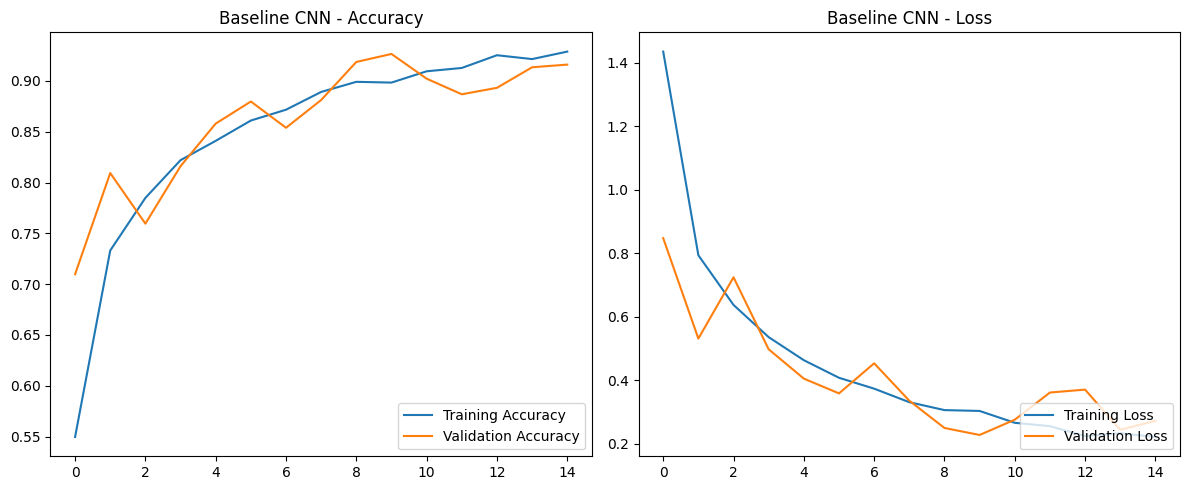

In [17]:
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('../models/cnn_best.keras', save_best_only=True)
    ]
)

plot_history(cnn_history, "Baseline CNN")

84/84 [==============================] - 6s 71ms/step

=== Baseline CNN = Test Results :
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.76      0.79        51
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       119
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.89      0.89        98
                            Corn_(maize)___healthy       0.98      1.00      0.99       116
                     Pepper,_bell___Bacterial_spot       0.85      0.94      0.90       100
                            Pepper,_bell___healthy       0.96      1.00      0.98       147
                             Potato___Early_blight       0.84      0.98      0.90       100
                              Potato___Late_blight       0.84      0.87      0.85       100
                                  Potato___healthy       1.00      0.73      0.85 

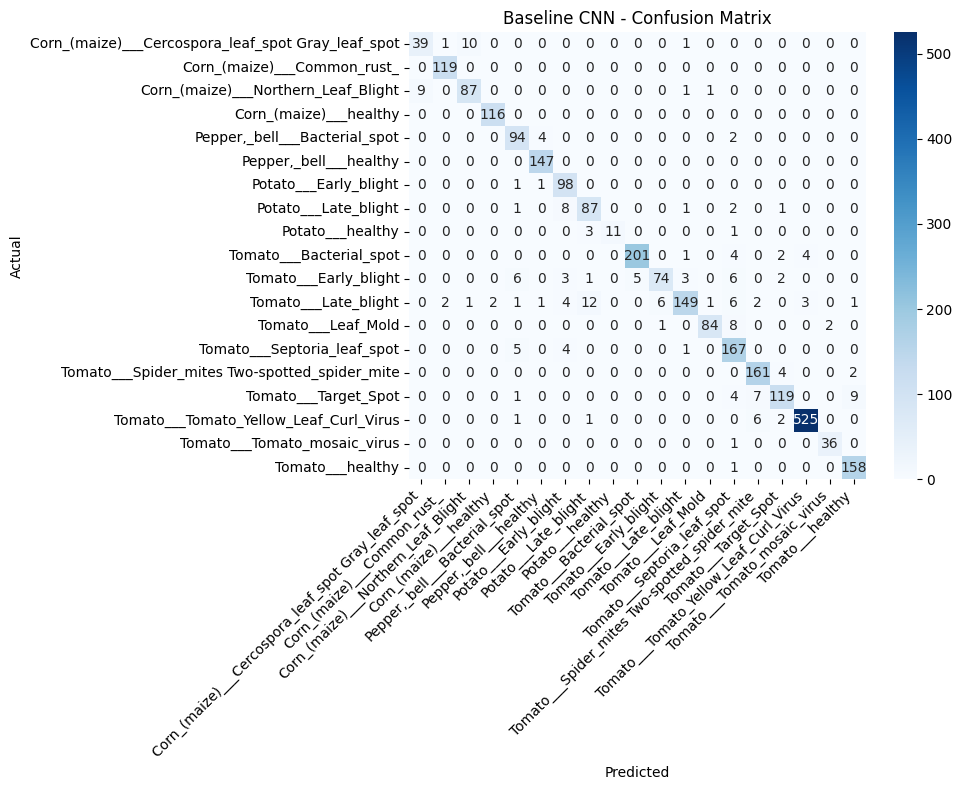

In [43]:
evaluate_on_test(cnn_model, 'Baseline CNN', test_generator)

# Model 2 - VGG16

**Phase 1:** Train only the new head (base frozen)
**Phase 2:** Fine-tune last 3 conv blocks

In [24]:
vgg16_base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False # Freeze all layers for phase 1

vgg16_model = models.Sequential([
    vgg16_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='VGG16')

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.summary()

58889256/58889256 [==============================] - 167s 3us/step
Model: "VGG16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 19)                4883      
                                                                 
Total params: 14,850,899
Trainable params: 136,211
Non-train

VGG16 - Phase 1: Training head (base frozen)
Epoch 1/20
666/666 [==============================] - 312s 468ms/step - loss: 42.0759 - accuracy: 0.2928 - val_loss: 19.0958 - val_accuracy: 0.4341
Epoch 2/20
666/666 [==============================] - 309s 463ms/step - loss: 19.5455 - accuracy: 0.4189 - val_loss: 10.6528 - val_accuracy: 0.5127
Epoch 3/20
666/666 [==============================] - 304s 456ms/step - loss: 12.8355 - accuracy: 0.4689 - val_loss: 7.2814 - val_accuracy: 0.5562
Epoch 4/20
666/666 [==============================] - 301s 452ms/step - loss: 9.9450 - accuracy: 0.5004 - val_loss: 5.8344 - val_accuracy: 0.5861
Epoch 5/20
666/666 [==============================] - 302s 452ms/step - loss: 8.4041 - accuracy: 0.5153 - val_loss: 5.0177 - val_accuracy: 0.6086
Epoch 6/20
666/666 [==============================] - 313s 469ms/step - loss: 7.3157 - accuracy: 0.5310 - val_loss: 4.3407 - val_accuracy: 0.6240
Epoch 7/20
666/666 [==============================] - 308s 462ms/step - lo

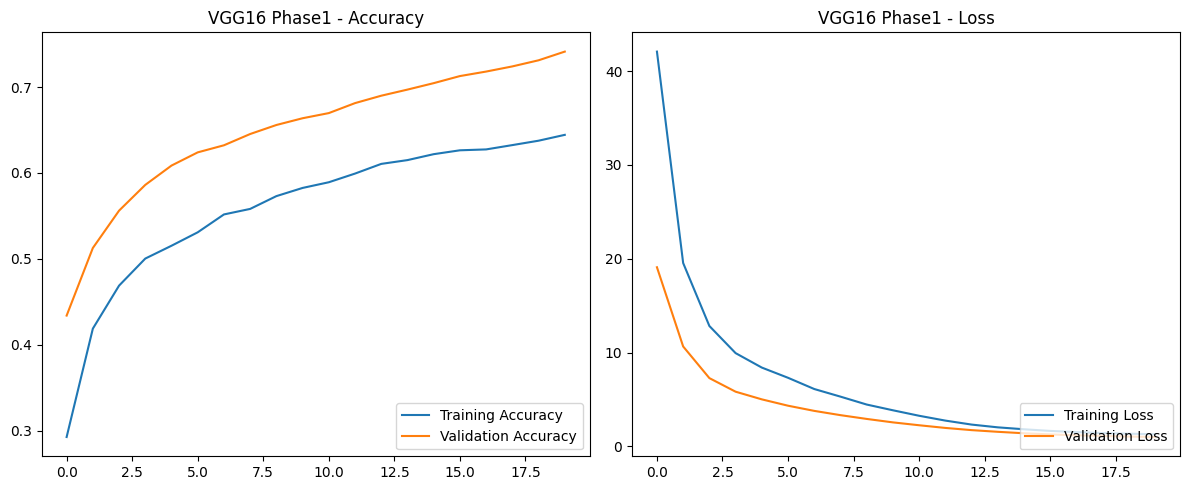

In [36]:
#Phase 1 - head only
print("VGG16 - Phase 1: Training head (base frozen)")

vgg16_history_p1 = vgg16_model.fit(
    vgg_train_generator,
    validation_data = vgg_val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('../models/vgg16_phase1.keras', save_best_only=True)
    ]
)

plot_history(vgg16_history_p1, "VGG16 Phase1")


VGG16 — Phase 2: Fine-tuning last 3 blocks
Epoch 1/50
666/666 [==============================] - 303s 453ms/step - loss: 1.2495 - accuracy: 0.6488 - val_loss: 0.9569 - val_accuracy: 0.7476
Epoch 2/50
666/666 [==============================] - 306s 459ms/step - loss: 1.2024 - accuracy: 0.6530 - val_loss: 0.9236 - val_accuracy: 0.7517
Epoch 3/50
666/666 [==============================] - 318s 477ms/step - loss: 1.1799 - accuracy: 0.6586 - val_loss: 0.8957 - val_accuracy: 0.7551
Epoch 4/50
666/666 [==============================] - 316s 474ms/step - loss: 1.1361 - accuracy: 0.6686 - val_loss: 0.8648 - val_accuracy: 0.7581
Epoch 5/50
666/666 [==============================] - 320s 480ms/step - loss: 1.0819 - accuracy: 0.6784 - val_loss: 0.8395 - val_accuracy: 0.7614
Epoch 6/50
666/666 [==============================] - 311s 467ms/step - loss: 1.0838 - accuracy: 0.6785 - val_loss: 0.8136 - val_accuracy: 0.7674
Epoch 7/50
666/666 [==============================] - 310s 466ms/step - loss: 1.0

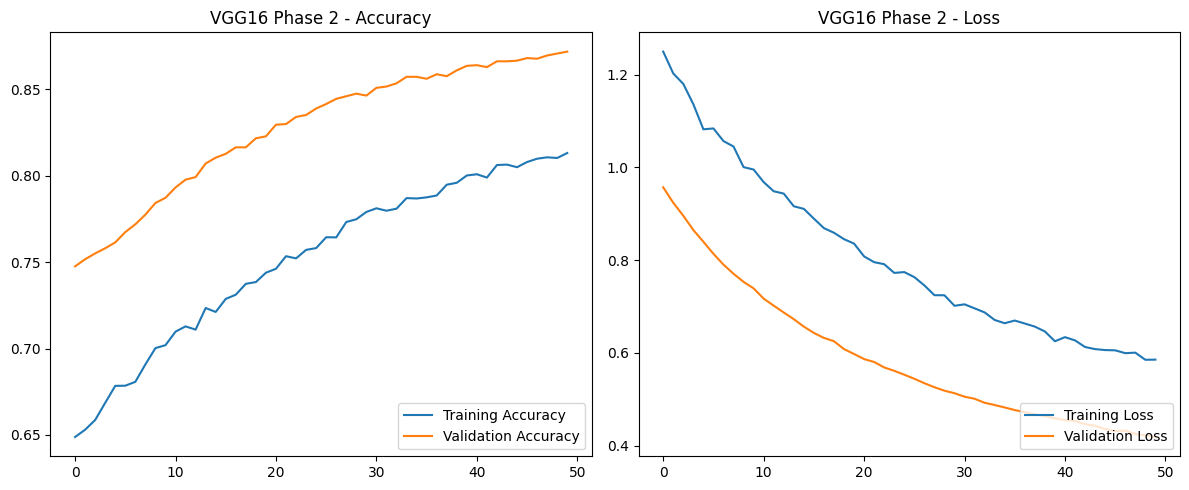

In [39]:
# Phase 2 — unfreeze last 3 blocks, lower learning rate
print("VGG16 — Phase 2: Fine-tuning last 3 blocks")

for layer in vgg16_base.layers:
    if layer.name.startswith(('block3', 'block4', 'block5')):
        layer.trainable = True

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_history_p2 = vgg16_model.fit(
    vgg_train_generator,
    validation_data=vgg_val_generator,
    epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ModelCheckpoint('../models/vgg16_best.keras', save_best_only=True)
    ]
)

plot_history(vgg16_history_p2, 'VGG16 Phase 2')

84/84 [==============================] - 9s 101ms/step

=== VGG16 = Test Results :
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.78      0.71      0.74        51
                       Corn_(maize)___Common_rust_       0.97      0.98      0.98       119
               Corn_(maize)___Northern_Leaf_Blight       0.83      0.88      0.86        98
                            Corn_(maize)___healthy       1.00      0.95      0.97       116
                     Pepper,_bell___Bacterial_spot       0.98      0.85      0.91       100
                            Pepper,_bell___healthy       0.94      0.99      0.96       147
                             Potato___Early_blight       0.96      0.93      0.94       100
                              Potato___Late_blight       0.90      0.83      0.86       100
                                  Potato___healthy       1.00      1.00      1.00       

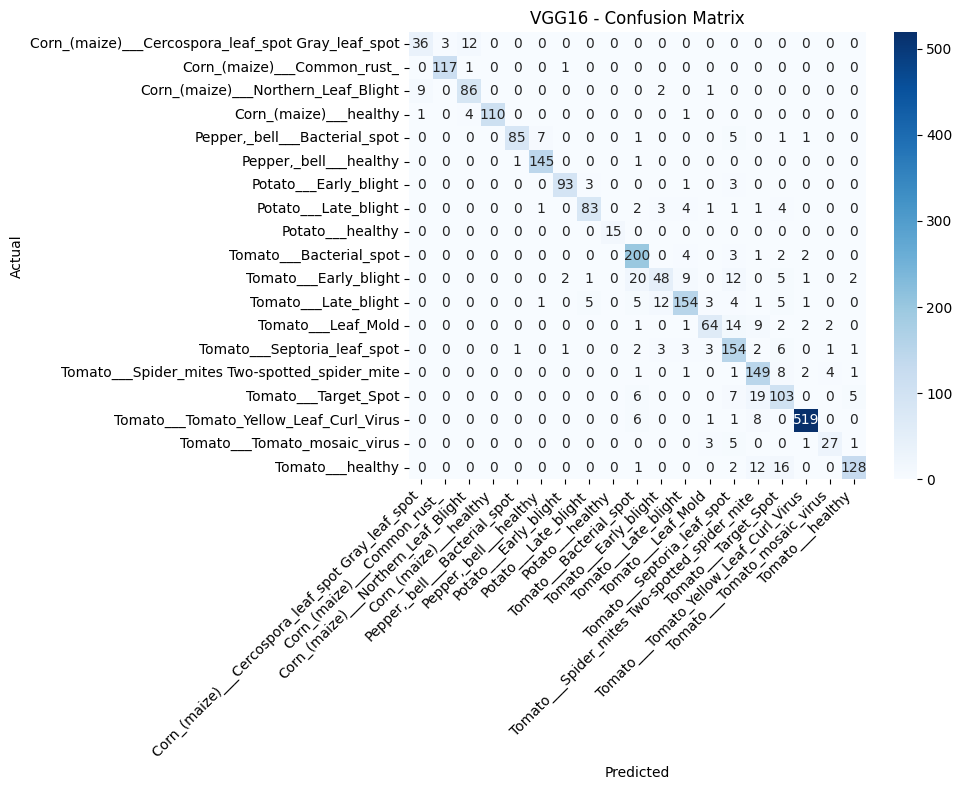

In [44]:
evaluate_on_test(vgg16_model, 'VGG16', vgg_test_generator)

In [12]:
vgg16_model = tf.keras.models.load_model('../models/vgg16_best.keras')
vgg16_model.trainable = False
vgg16_model.save('../models/vgg16_best', save_format='tf')
print("VGG16 saved as SavedModel")

INFO:tensorflow:Assets written to: ../models/vgg16_best\assets


INFO:tensorflow:Assets written to: ../models/vgg16_best\assets


VGG16 saved as SavedModel


# Model 3 - VGG19

In [45]:
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg19_base.trainable = False

vgg19_model = models.Sequential([
    vgg19_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='VGG19')

vgg19_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

80134624/80134624 [==============================] - 1243s 16us/step


VGG19 - Phase 1: Training head (base frozen)
Epoch 1/20
666/666 [==============================] - 319s 478ms/step - loss: 2.3148 - accuracy: 0.4300 - val_loss: 0.9756 - val_accuracy: 0.7060
Epoch 2/20
666/666 [==============================] - 358s 537ms/step - loss: 1.1071 - accuracy: 0.6515 - val_loss: 0.6589 - val_accuracy: 0.7955
Epoch 3/20
666/666 [==============================] - 473s 709ms/step - loss: 0.8381 - accuracy: 0.7334 - val_loss: 0.5268 - val_accuracy: 0.8348
Epoch 4/20
666/666 [==============================] - 760s 1s/step - loss: 0.6905 - accuracy: 0.7774 - val_loss: 0.4489 - val_accuracy: 0.8581
Epoch 5/20
666/666 [==============================] - 325s 487ms/step - loss: 0.5976 - accuracy: 0.8067 - val_loss: 0.4135 - val_accuracy: 0.8622
Epoch 6/20
666/666 [==============================] - 320s 480ms/step - loss: 0.5321 - accuracy: 0.8245 - val_loss: 0.3854 - val_accuracy: 0.8753
Epoch 7/20
666/666 [==============================] - 327s 491ms/step - loss: 0.48

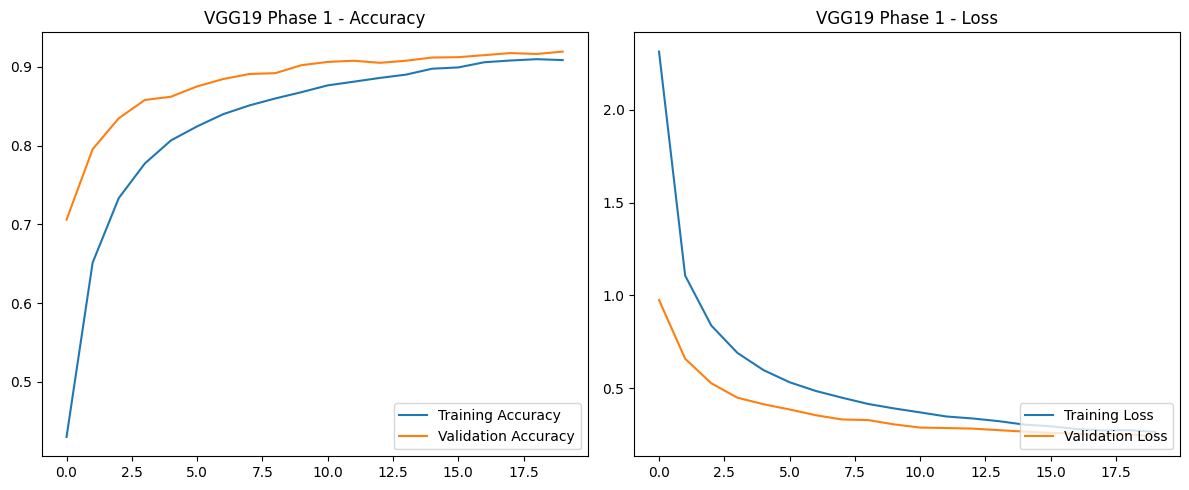

In [46]:
# Phase 1
print("VGG19 - Phase 1: Training head (base frozen)")

vgg19_history_p1 = vgg19_model.fit(
    vgg19_train_generator,
    validation_data=vgg19_val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('../models/vgg19_phase1.keras', cave_best_only=True)
    ]
)

plot_history(vgg19_history_p1, 'VGG19 Phase 1')

VGG19 - Phase 2: Fine-tuning last 3 blocks
Epoch 1/50
666/666 [==============================] - 318s 474ms/step - loss: 0.2426 - accuracy: 0.9183 - val_loss: 0.2365 - val_accuracy: 0.9184
Epoch 2/50
666/666 [==============================] - 321s 481ms/step - loss: 0.2372 - accuracy: 0.9206 - val_loss: 0.2342 - val_accuracy: 0.9184
Epoch 3/50
666/666 [==============================] - 320s 480ms/step - loss: 0.2397 - accuracy: 0.9171 - val_loss: 0.2359 - val_accuracy: 0.9187
Epoch 4/50
666/666 [==============================] - 320s 480ms/step - loss: 0.2344 - accuracy: 0.9188 - val_loss: 0.2375 - val_accuracy: 0.9176
Epoch 5/50
666/666 [==============================] - 320s 480ms/step - loss: 0.2362 - accuracy: 0.9201 - val_loss: 0.2353 - val_accuracy: 0.9161
Epoch 6/50
666/666 [==============================] - 320s 480ms/step - loss: 0.2328 - accuracy: 0.9189 - val_loss: 0.2357 - val_accuracy: 0.9172
Epoch 7/50
666/666 [==============================] - 320s 480ms/step - loss: 0.2

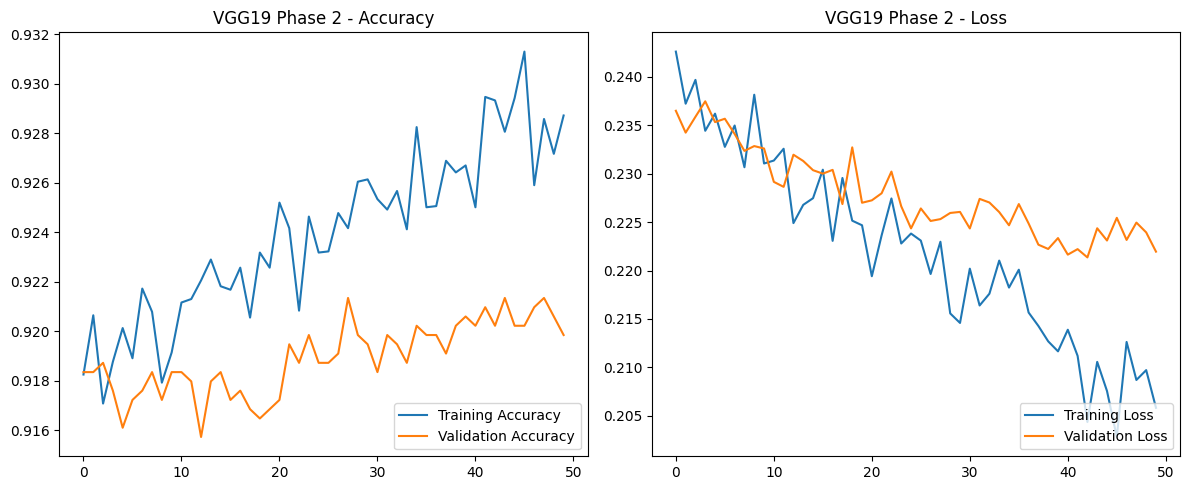

In [47]:
# Phase 2
print("VGG19 - Phase 2: Fine-tuning last 3 blocks")

for layer in vgg19_base.layers:
    if layer.name.startswith(('block3', 'block4', 'block5')):
        layer.trainable = True

vgg19_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg19_history_p2 = vgg19_model.fit(
    vgg19_train_generator,
    validation_data= vgg19_val_generator,
    epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ModelCheckpoint('../models/vgg19_best.keras', save_best_only=True)
    ]
)

plot_history(vgg19_history_p2, 'VGG19 Phase 2')

84/84 [==============================] - 10s 119ms/step

=== VGG19 = Test Results :
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.86      0.85        51
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       119
               Corn_(maize)___Northern_Leaf_Blight       0.94      0.93      0.93        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                     Pepper,_bell___Bacterial_spot       0.99      0.97      0.98       100
                            Pepper,_bell___healthy       0.99      1.00      0.99       147
                             Potato___Early_blight       0.98      1.00      0.99       100
                              Potato___Late_blight       0.97      0.98      0.98       100
                                  Potato___healthy       1.00      0.93      0.97      

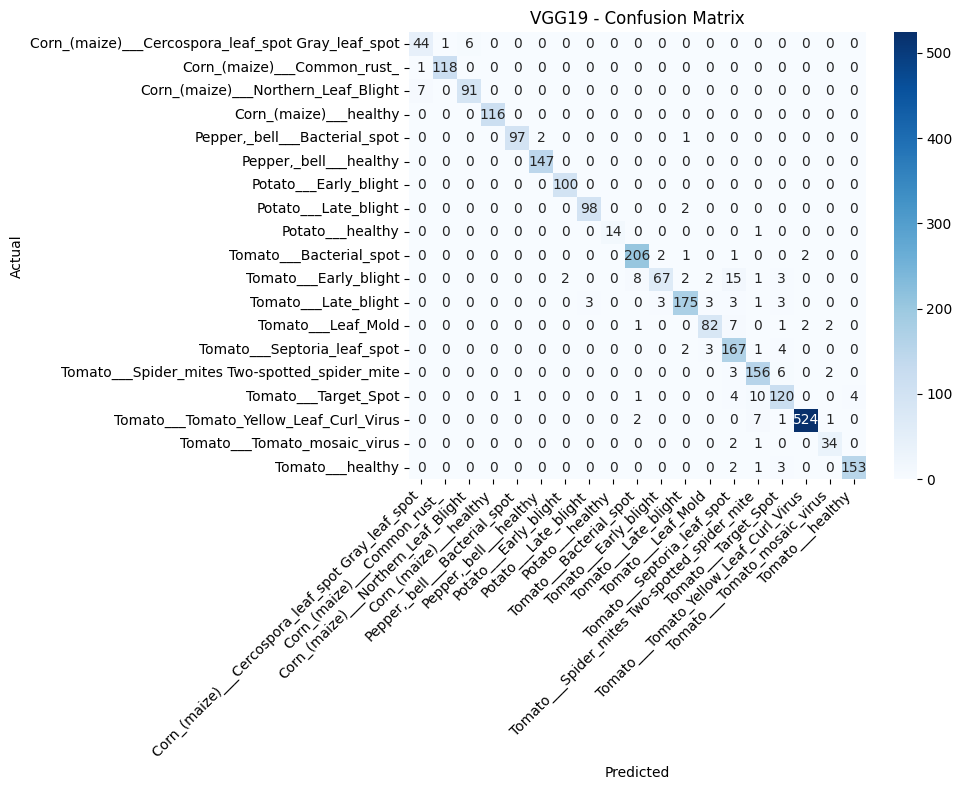

In [48]:
evaluate_on_test(vgg19_model, 'VGG19', vgg19_test_generator)

In [13]:
vgg19_model = tf.keras.models.load_model('../models/vgg19_best.keras')
vgg19_model.trainable = False
vgg19_model.save('../models/vgg19_best', save_format='tf')
print("VGG19 saved as SavedModel")

INFO:tensorflow:Assets written to: ../models/vgg19_best\assets


INFO:tensorflow:Assets written to: ../models/vgg19_best\assets


VGG19 saved as SavedModel


# Model 4 - EfficientNetB0

In [16]:
effb0_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
effb0_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = effb0_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

effb0_model = tf.keras.Model(inputs, outputs, name='EfficientNetB0')

effb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EfficientNetB0 - Phase 1: Training head (base frozen
Epoch 1/20
666/666 [==============================] - 314s 472ms/step - loss: 0.3702 - accuracy: 0.8855 - val_loss: 0.2844 - val_accuracy: 0.9124
Epoch 2/20
666/666 [==============================] - 317s 476ms/step - loss: 0.3274 - accuracy: 0.9004 - val_loss: 0.2617 - val_accuracy: 0.9146
Epoch 3/20
666/666 [==============================] - 330s 495ms/step - loss: 0.3063 - accuracy: 0.9029 - val_loss: 0.2474 - val_accuracy: 0.9232
Epoch 4/20
666/666 [==============================] - 332s 497ms/step - loss: 0.2712 - accuracy: 0.9153 - val_loss: 0.2303 - val_accuracy: 0.9258
Epoch 5/20
666/666 [==============================] - 341s 511ms/step - loss: 0.2544 - accuracy: 0.9197 - val_loss: 0.2241 - val_accuracy: 0.9288
Epoch 6/20
666/666 [==============================] - 339s 508ms/step - loss: 0.2359 - accuracy: 0.9242 - val_loss: 0.2098 - val_accuracy: 0.9277
Epoch 7/20
666/666 [==============================] - 344s 517ms/step -

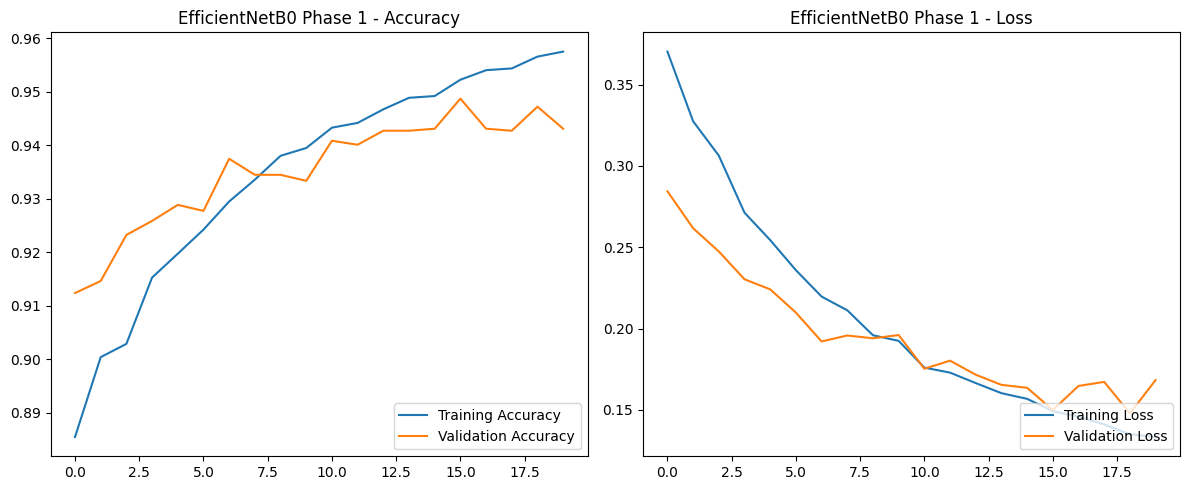

In [22]:
# Phase 1
print('EfficientNetB0 - Phase 1: Training head (base frozen')

effb0_history_p1 = effb0_model.fit(
    efficientNet_train_generator,
    validation_data=efficientNet_val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(
            '../models/effb0_phase1_weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True 
        )
    ]
)

plot_history(effb0_history_p1, 'EfficientNetB0 Phase 1')

EfficientNetB0 — Phase 2: Fine-tuning last 30 layers
Epoch 1/50
666/666 [==============================] - 339s 492ms/step - loss: 0.3728 - accuracy: 0.8926 - val_loss: 0.2117 - val_accuracy: 0.9318
Epoch 2/50
666/666 [==============================] - 327s 491ms/step - loss: 0.2314 - accuracy: 0.9284 - val_loss: 0.1713 - val_accuracy: 0.9408
Epoch 3/50
666/666 [==============================] - 330s 495ms/step - loss: 0.1895 - accuracy: 0.9400 - val_loss: 0.1521 - val_accuracy: 0.9472
Epoch 4/50
666/666 [==============================] - 335s 502ms/step - loss: 0.1648 - accuracy: 0.9468 - val_loss: 0.1375 - val_accuracy: 0.9536
Epoch 5/50
666/666 [==============================] - 334s 502ms/step - loss: 0.1490 - accuracy: 0.9512 - val_loss: 0.1293 - val_accuracy: 0.9551
Epoch 6/50
666/666 [==============================] - 355s 533ms/step - loss: 0.1376 - accuracy: 0.9564 - val_loss: 0.1243 - val_accuracy: 0.9562
Epoch 7/50
666/666 [==============================] - 355s 533ms/step -

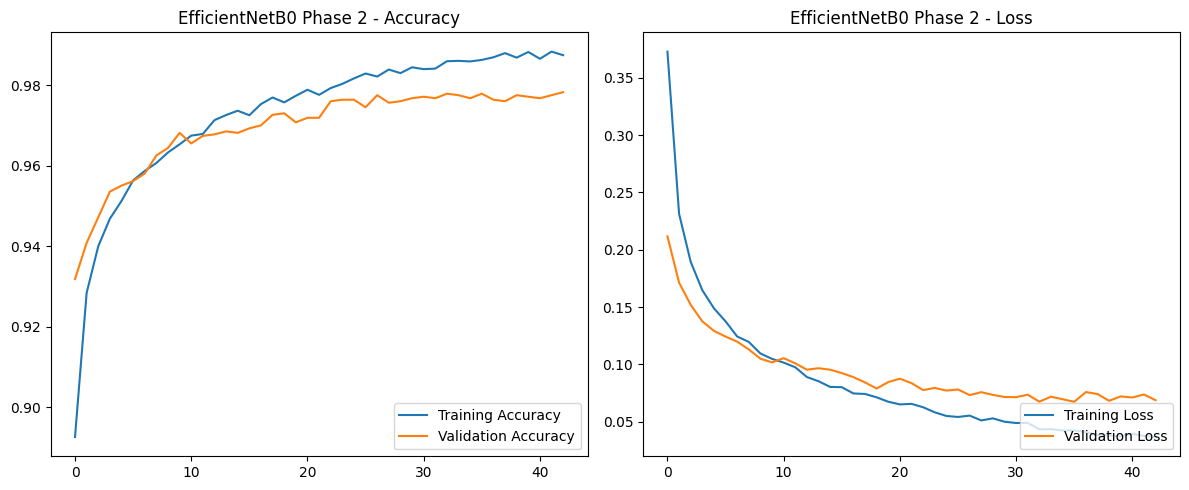

In [23]:
# Phase 2 — unfreeze last 30 layers
print("EfficientNetB0 — Phase 2: Fine-tuning last 30 layers")

effb0_base.trainable = True
for layer in effb0_base.layers[:-30]:
    layer.trainable = False

effb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effb0_history_p2 = effb0_model.fit(
    efficientNet_train_generator,
    validation_data=efficientNet_val_generator,
    epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ModelCheckpoint(
            '../models/effb0_best_weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True
        )
    ]
)

plot_history(effb0_history_p2, 'EfficientNetB0 Phase 2')

84/84 [==============================] - 10s 86ms/step

=== EfficientNetB0 = Test Results :
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.78      0.84        51
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       119
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.96      0.92        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                     Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       100
                            Pepper,_bell___healthy       1.00      0.99      1.00       147
                             Potato___Early_blight       0.99      1.00      1.00       100
                              Potato___Late_blight       1.00      1.00      1.00       100
                                  Potato___healthy       0.94      1.00      0.

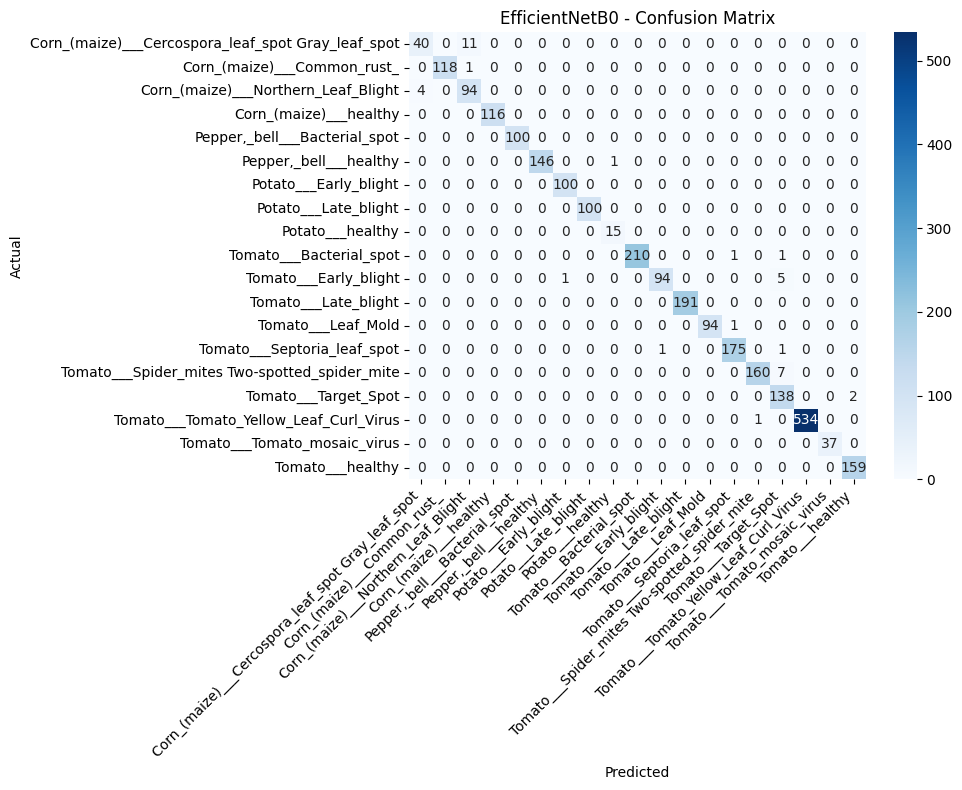

In [24]:
evaluate_on_test(effb0_model, 'EfficientNetB0', efficientNet_test_generator)

In [ ]:
tf.saved_model.save(effb0_model, '../models/effb0_best')
print("✅ EfficientNetB0 saved as SavedModel")

# Model 5 - EfficientNetB3

In [8]:
effb3_base = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
effb3_base.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = effb3_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

effb3_model = tf.keras.Model(inputs, outputs, name='EfficientNetB3')

effb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

43941136/43941136 [==============================] - 27s 1us/step


EfficientNetB3 - Phase 1: Training head (base frozen
Epoch 1/20
666/666 [==============================] - 134s 187ms/step - loss: 1.4279 - accuracy: 0.5857 - val_loss: 0.7561 - val_accuracy: 0.7996
Epoch 2/20
666/666 [==============================] - 130s 195ms/step - loss: 0.7331 - accuracy: 0.7780 - val_loss: 0.5312 - val_accuracy: 0.8502
Epoch 3/20
666/666 [==============================] - 133s 200ms/step - loss: 0.5673 - accuracy: 0.8236 - val_loss: 0.4312 - val_accuracy: 0.8730
Epoch 4/20
666/666 [==============================] - 137s 206ms/step - loss: 0.4819 - accuracy: 0.8517 - val_loss: 0.3745 - val_accuracy: 0.8865
Epoch 5/20
666/666 [==============================] - 137s 205ms/step - loss: 0.4274 - accuracy: 0.8659 - val_loss: 0.3331 - val_accuracy: 0.8959
Epoch 6/20
666/666 [==============================] - 139s 209ms/step - loss: 0.3837 - accuracy: 0.8795 - val_loss: 0.3110 - val_accuracy: 0.9056
Epoch 7/20
666/666 [==============================] - 137s 205ms/step -

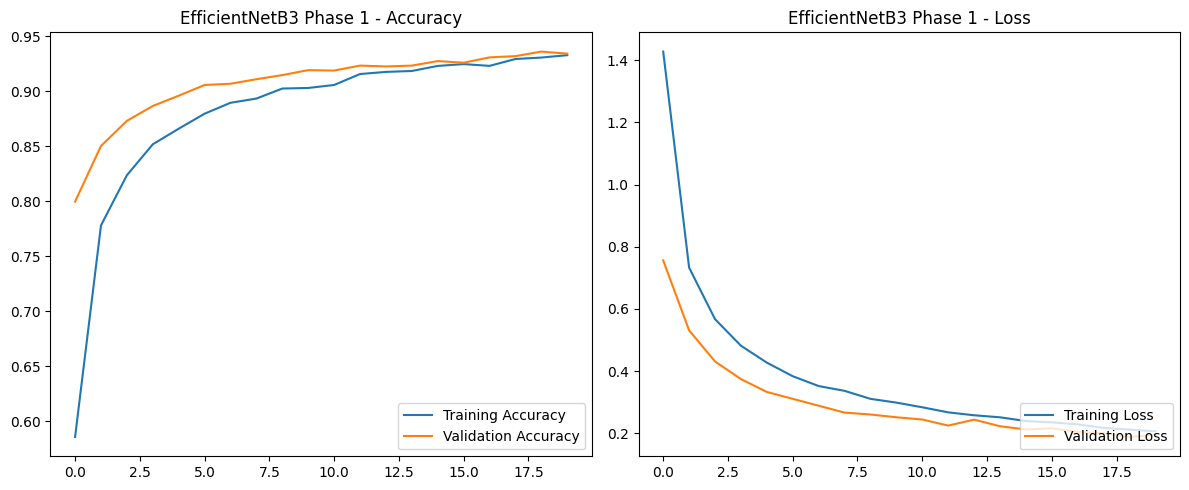

In [9]:
# Phase 1
print('EfficientNetB3 - Phase 1: Training head (base frozen')

effb3_history_p1 = effb3_model.fit(
    efficientNet_train_generator,
    validation_data=efficientNet_val_generator,
    epochs=20,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(
            '../models/effb3_phase1_weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True 
        )
    ]
)

plot_history(effb3_history_p1, 'EfficientNetB3 Phase 1')

EfficientNetB3 — Phase 2: Fine-tuning last 30 layers
Epoch 1/50
666/666 [==============================] - 126s 182ms/step - loss: 0.4901 - accuracy: 0.8535 - val_loss: 0.2732 - val_accuracy: 0.9139
Epoch 2/50
666/666 [==============================] - 137s 205ms/step - loss: 0.3209 - accuracy: 0.8976 - val_loss: 0.2166 - val_accuracy: 0.9281
Epoch 3/50
666/666 [==============================] - 143s 215ms/step - loss: 0.2669 - accuracy: 0.9147 - val_loss: 0.1842 - val_accuracy: 0.9371
Epoch 4/50
666/666 [==============================] - 144s 216ms/step - loss: 0.2338 - accuracy: 0.9229 - val_loss: 0.1622 - val_accuracy: 0.9472
Epoch 5/50
666/666 [==============================] - 142s 213ms/step - loss: 0.1984 - accuracy: 0.9357 - val_loss: 0.1507 - val_accuracy: 0.9468
Epoch 6/50
666/666 [==============================] - 147s 220ms/step - loss: 0.1845 - accuracy: 0.9395 - val_loss: 0.1377 - val_accuracy: 0.9539
Epoch 7/50
666/666 [==============================] - 147s 221ms/step -

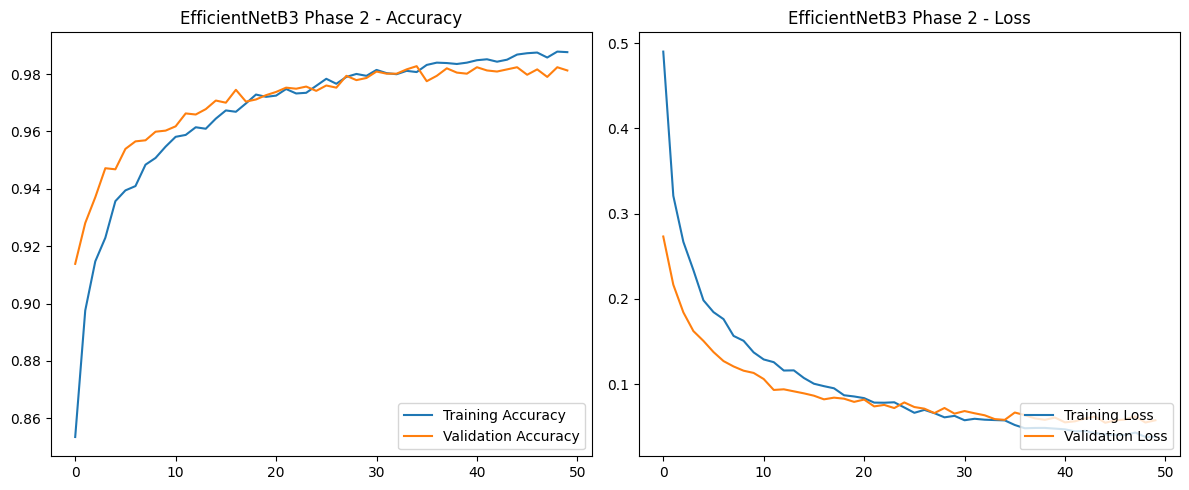

In [10]:
# Phase 2 — unfreeze last 30 layers
print("EfficientNetB3 — Phase 2: Fine-tuning last 30 layers")

effb3_base.trainable = True
for layer in effb3_base.layers[:-30]:
    layer.trainable = False

effb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effb3_history_p2 = effb3_model.fit(
    efficientNet_train_generator,
    validation_data=efficientNet_val_generator,
    epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        ModelCheckpoint(
            '../models/effb3_best_weights.h5',
            monitor='val_accuracy',
            save_best_only=True,
            save_weights_only=True
        )
    ]
)

plot_history(effb3_history_p2, 'EfficientNetB3 Phase 2')

84/84 [==============================] - 11s 89ms/step

=== EfficientNetB3 = Test Results :
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.82      0.88        51
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       119
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.98      0.95        98
                            Corn_(maize)___healthy       1.00      1.00      1.00       116
                     Pepper,_bell___Bacterial_spot       1.00      1.00      1.00       100
                            Pepper,_bell___healthy       1.00      1.00      1.00       147
                             Potato___Early_blight       1.00      0.99      0.99       100
                              Potato___Late_blight       0.99      1.00      1.00       100
                                  Potato___healthy       1.00      1.00      1.

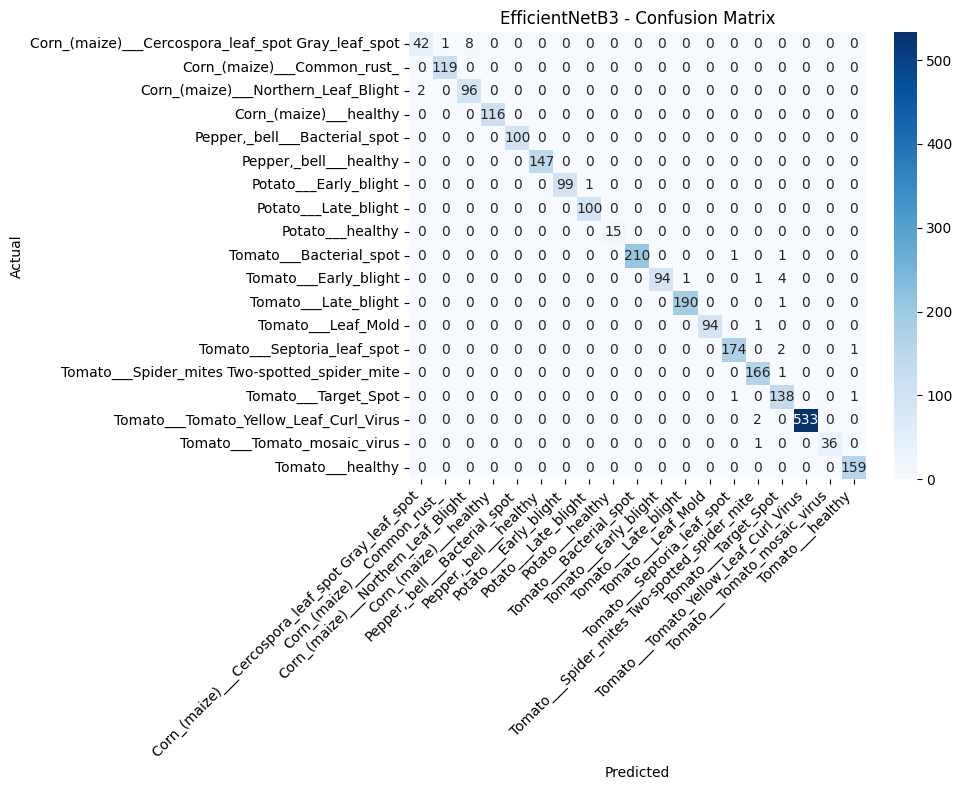

In [11]:
evaluate_on_test(effb3_model, 'EfficientNetB3', efficientNet_test_generator)

In [12]:
tf.saved_model.save(effb3_model, '../models/effb3_best')
print("✅ EfficientNetB3 saved as SavedModel")

INFO:tensorflow:Assets written to: ../models/effb3_best\assets


INFO:tensorflow:Assets written to: ../models/effb3_best\assets


✅ EfficientNetB3 saved as SavedModel


In [17]:
# Generator only for visualization
efficientNet_viz_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
efficientNet_viz_generator = efficientNet_viz_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True  
)

images, labels = next(efficientNet_viz_generator)

Found 2659 images belonging to 19 classes.


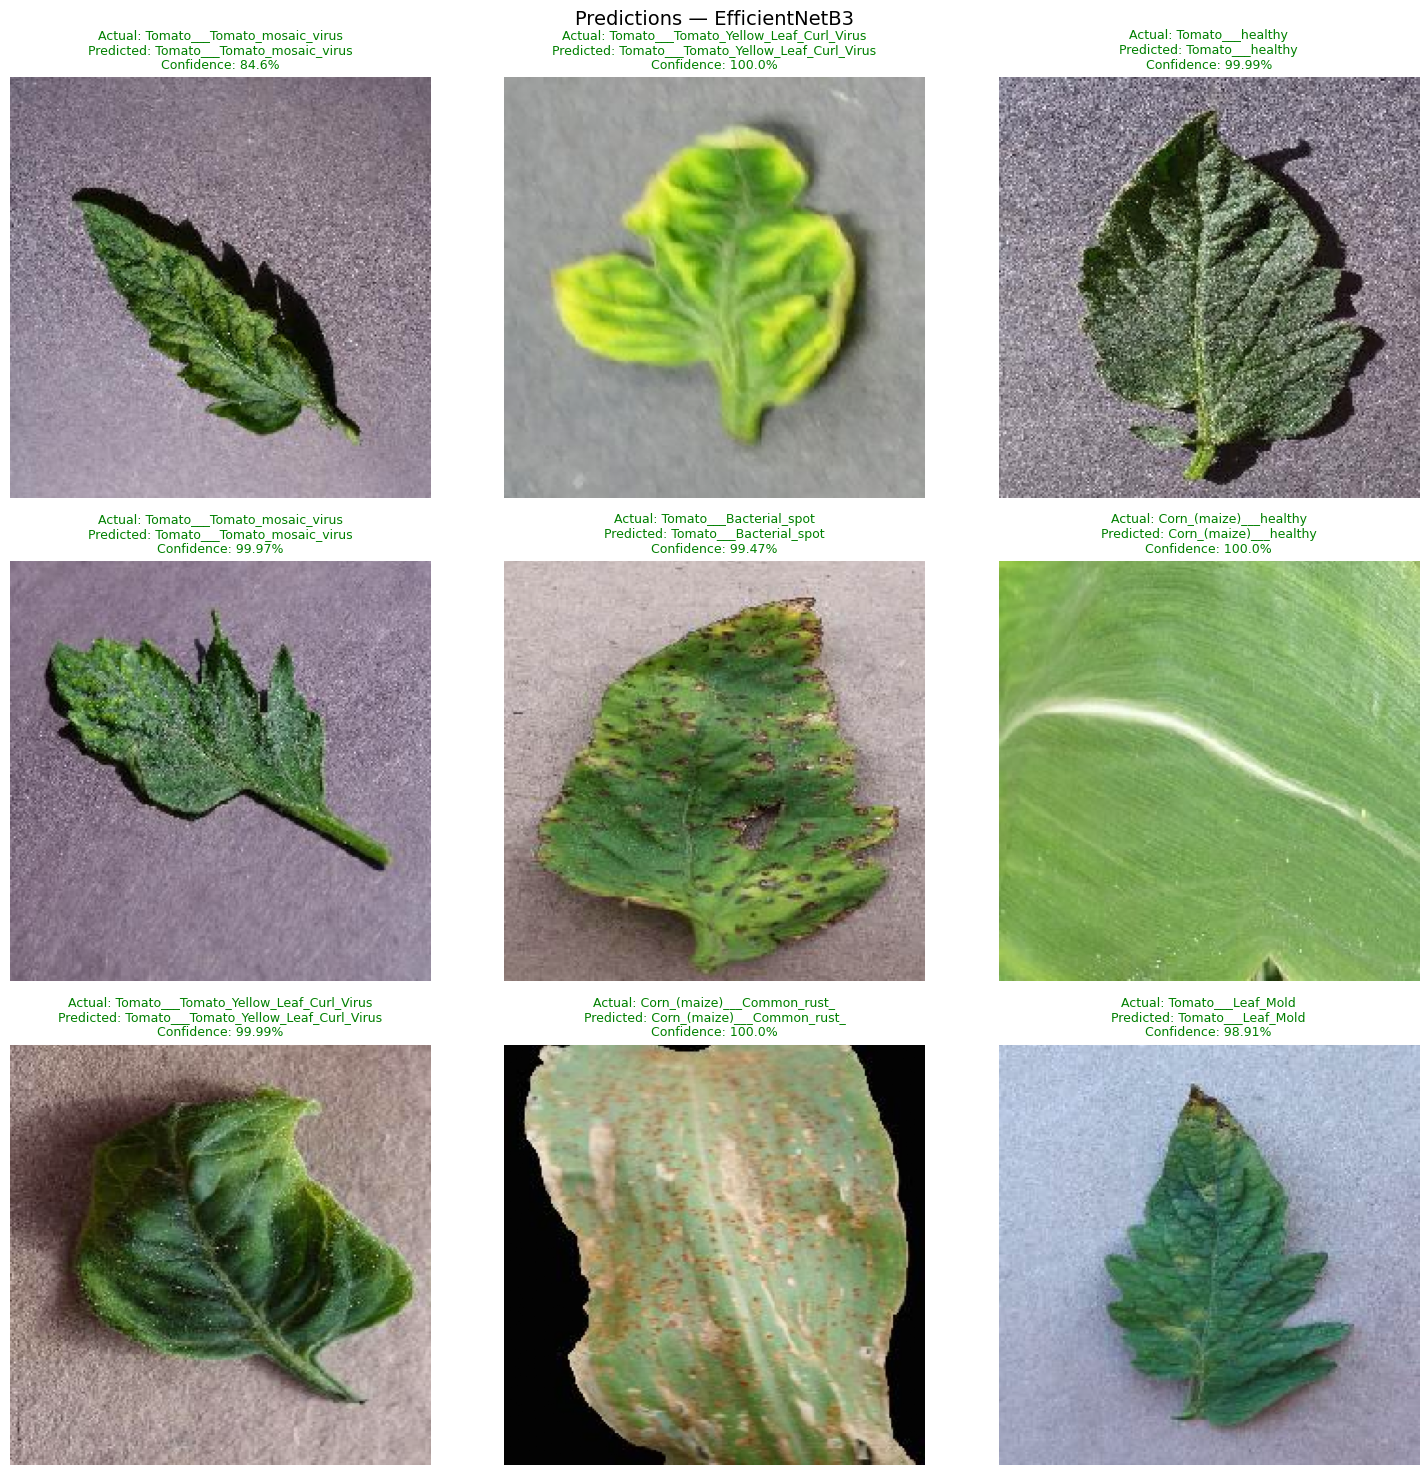

In [18]:
def predict(model, img_array):
    img_array = tf.expand_dims(img_array, 0) 
    predictions = model.predict(img_array, verbose=0)
    predicted_class = CLASS_NAMES[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence


# Preview predictions on test images
images, labels = next(efficientNet_viz_generator)

plt.figure(figsize=(15, 15))
for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    
    img = images[i].copy()
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)

    predicted_class, confidence = predict(effb3_model, images[i])
    actual_class = CLASS_NAMES[np.argmax(labels[i])]

    color = 'green' if predicted_class == actual_class else 'red'
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%",
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle(f'Predictions — EfficientNetB3', fontsize=14)
plt.tight_layout()
plt.show()